In [5]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [6]:
DT_US = 0.004      # 4 ns / sample (250 MSa/s)
R_OHM = 10.0

In [7]:
def load_v(path):
    with open(path, newline="") as fh:
        r = csv.reader(fh); next(r, None)
        return np.array([float(row[1]) for row in r if len(row) >= 2])


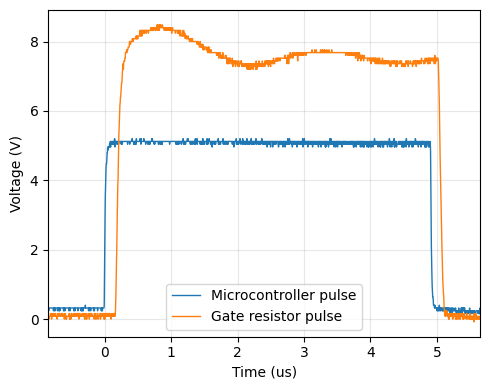

In [8]:
# ---------- Plot 1: arduino vs resistor ----------
va = load_v("waveforms/gate_component/waveform_arduino.csv")
vr = load_v("waveforms/gate_component/waveform_resistor.csv")
T0 = 28.85
ta = np.arange(va.size) * DT_US - T0
tr = np.arange(vr.size) * DT_US - T0
 
fig1, ax1 = plt.subplots(figsize=(5, 4))
ax1.plot(ta, va, lw=1.0, label="Microcontroller pulse")
ax1.plot(tr, vr, lw=1.0, label="Gate resistor pulse")
ax1.set_xlim(28 - T0, 34.5 - T0)
ax1.set_xlabel("Time (us)")
ax1.set_ylabel("Voltage (V)")
#ax1.set_title("Gate driver pulses")
ax1.grid(True, alpha=0.3)
ax1.legend()
fig1.tight_layout()


[8177 8178 8179 8180 8181 8182 8183 8184 8185 8186 8187 8188 8189 8190
 8191 8192 8193]


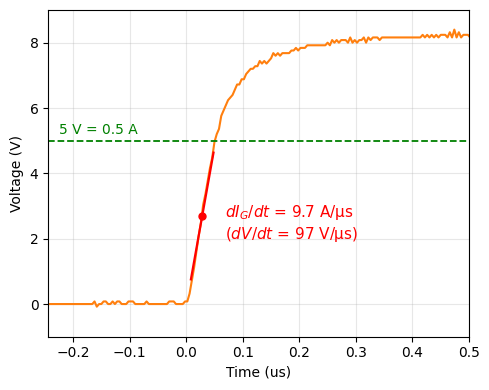

In [9]:
# ---------- Plot 2: zoomed resistor rising edge ----------
vz_raw = load_v("waveforms/gate_component/waveform_resistor_zoomed.csv")
T0 = 32.71
zbase = np.median(vz_raw[200:7000])          # low level -> 0
vz = vz_raw - zbase
tz = np.arange(vz.size) * DT_US - T0
 
# locate the rising edge
on = 8175
while vz[on] < 0.4:
    on += 1
on -= 1
j = on
while vz[j] < 5.0:
    j += 1
t5 = tz[j - 1] + (5.0 - vz[j - 1]) * (tz[j] - tz[j - 1]) / (vz[j] - vz[j - 1])
t_on = tz[on]
t_mid = 0.5 * (t_on + t5)
 
# tangent: local linear fit around the midpoint
mid_i = (on + j) // 2
s = np.arange(mid_i - 8, mid_i + 9)
slope, intercept = np.polyfit(tz[s], vz[s], 1)
didt = slope / R_OHM                              # A/us
print(s)
 
fig2, ax2 = plt.subplots(figsize=(5, 4))
ax2.plot(tz, vz, color="tab:orange")
ax2.set_xlim(t_on - 0.25, t5 + 0.45)
ax2.set_ylim(-1, 9)
 
# 5 V = 0.5 A line
ax2.axhline(5.0, color="green", ls="--", lw=1.3)
ax2.text(ax2.get_xlim()[0] + 0.02, 5.2, "5 V = 0.5 A", color="green", fontsize=10)
 
# tangent through the midpoint
tt = np.array([t_mid - 0.02, t_mid + 0.02])
ax2.plot(tt, slope * tt + intercept, color="red", lw=1.6)
ax2.plot(t_mid, slope * t_mid + intercept, "ro", ms=5)
ax2.annotate(f"$dI_G/dt$ = {didt:.1f} A/\u00b5s\n($dV/dt$ = {slope:.0f} V/\u00b5s)",
             xy=(t_mid, slope * t_mid + intercept),
             xytext=(t_mid + 0.04, 2.0),
             color="red", fontsize=11)
 
ax2.set_xlabel("Time (us)")
ax2.set_ylabel("Voltage (V)")
#ax2.set_title("Gate resistor voltage rising edge")
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
